- BY - Oliver Tschudi Madsen
- GITHUB - https://github.com/OTMadsen/IND320
- Streamlit - 

In [12]:
#These are the libraries used for this Notebook
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

- AI models used 
    - Gemini AI (used for correction or error searching in both notebook and streamlit app)
    - As well as generating some of the code for the streamlit app. 

Import the CSV file using a Pandas Dataframe and using the head function just to get the first few lines of data for simplicity. This gives an overview of what kind of information we are working with in this assignment. 

In [13]:
#Simple datframe with Pandas, seperated with "," since we have a csv-file. 
df = pd.read_csv('reservoirs.csv', sep=',')

print(df.head(5))

      dato_Id omrType  omrnr  iso_aar  iso_uke  fyllingsgrad  kapasitet_TWh  \
0  1995-09-03      EL      4     1995       35      0.944721      21.079208   
1  2020-11-15      EL      1     2020       46      0.974361       6.003264   
2  2011-08-28      EL      4     2011       34      0.786499      21.079208   
3  1998-07-05      EL      3     1998       27      0.793969       8.920932   
4  2011-03-27      EL      4     2011       12      0.300820      21.079208   

   fylling_TWh neste_Publiseringsdato  fyllingsgrad_forrige_uke  \
0    19.913979    0001-01-01T00:00:00                  0.936888   
1     5.849344    2020-11-25T13:00:00                  0.997406   
2    16.578772    0001-01-01T00:00:00                  0.787193   
3     7.082947    0001-01-01T00:00:00                  0.733812   
4     6.341054    0001-01-01T00:00:00                  0.311122   

   endring_fyllingsgrad  
0              0.007833  
1             -0.023046  
2             -0.000694  
3              0.0

First task implies to rename headers to English to improve readability. This is done by just reading the file again and then mapping out the columns and replacing the norwegian headers with the new english and improved letters. By using the "rename"-action, the headers are now changed to English, with changed names as well. 

In [14]:
df = pd.read_csv('reservoirs.csv')
#Mapping of the existing file, and their new improved names. 
column_mapping = {

    "dato_Id" : "Date",
    "omrType" : "Area_Type",
    "omrnr"  : "Area_Number",
    "iso_aar" : "Iso_Year",
    "iso_uke" : "Iso_Week",
    "fyllingsgrad": "Fillings_Degree",
    "kapasitet_TWh" : "Capacity_TWh",
    "fylling_TWh" : "Filling_TWh",
    "neste_Publiseringsdato" : "Next_Publication_Date", 
    "fyllingsgrad_forrige_uke" : "Filling_Degree_Last_Week",
    "endring_fyllingsgrad" : "Change_Filling_Degree"}

#Simple renaming
df.rename(columns=column_mapping, inplace=True)

#Organizing by dates
df['Date'] = pd.to_datetime(df['Date'])

df = df.sort_values(by='Date')

df = df.reset_index(drop=True)
#New and improved dataset. 
df.to_csv('reservoirs_improved.csv', index=False)


print(df.head(5))


        Date Area_Type  Area_Number  Iso_Year  Iso_Week  Fillings_Degree  \
0 1995-01-08        EL            5      1995         1         0.616448   
1 1995-01-08        EL            4      1995         1         0.558864   
2 1995-01-08        EL            3      1995         1         0.602376   
3 1995-01-08        EL            1      1995         1         0.621467   
4 1995-01-08        EL            2      1995         1         0.630947   

   Capacity_TWh  Filling_TWh Next_Publication_Date  Filling_Degree_Last_Week  \
0     17.390587    10.720388   0001-01-01T00:00:00                  0.614288   
1     21.079208    11.780413   0001-01-01T00:00:00                  0.801348   
2      8.920932     5.373754   0001-01-01T00:00:00                  0.596027   
3      6.003264     3.730831   0001-01-01T00:00:00                  0.734888   
4     34.043590    21.479713   0001-01-01T00:00:00                  0.777604   

   Change_Filling_Degree  
0               0.002160  
1       

Now, to plot some of the columns, there are a few steps to be done. There are not all of the columns that are numerical, and therefore is not suited to be plotted withs say graphs or distributions. By sorting out the numerical columns as done below, we can plot them appropriately. 

By using max- and min-values we can find absolute values in the columns so it is possible later to apply Min-Max normalization for the numerical columns. We also add in that maximum is not equal to minimum to ensure that there are no zero-divisions. Finally using the max-min normalization we can limit the normalization between 0 and 1 for simplicity, since we are plotting several columns together. 

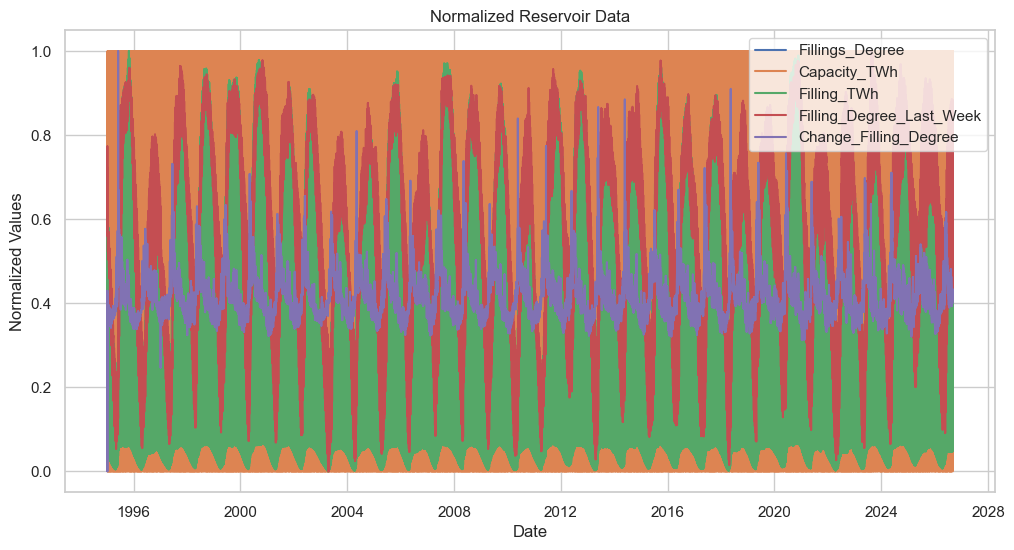

In [16]:
 
reservoirs_improved = df.copy()
#The columns we wish to plot. 

numerical_columns = [
    "Fillings_Degree",
    "Capacity_TWh",
    "Filling_TWh",
    "Filling_Degree_Last_Week",
    "Change_Filling_Degree"
]

#Loop for the numerical columns and finding the max and min. 
for col in numerical_columns:
    mn, mx = reservoirs_improved[col].min(), reservoirs_improved[col].max()
    if mx != mn:
        reservoirs_improved[col] = (
            reservoirs_improved[col] - mn
        ) / (mx - mn)


plt.figure(figsize=(12, 6))

for col in numerical_columns:
    plt.plot(reservoirs_improved["Date"], reservoirs_improved[col], label=col)

plt.title("Normalized Reservoir Data")
plt.xlabel("Date")
plt.ylabel("Normalized Values")
plt.legend(loc="upper right")
plt.show()



Then I plot the graphs separatly, with seaborn here as an additional plotting tool. The following plots displays development in fillings degree, capacity in "TWh" sorted by price area, a distribution weekly change og fillling degree and finally the seasonal pattern based on Iso Weeks

One of the intial code snippets (df_no and df_el) is made  to sort out national data and bidding zone data for clearer plots later. 

Furthermore the different columns are plotted using both seaborn and matplotlib for a better visualization of our given data. 


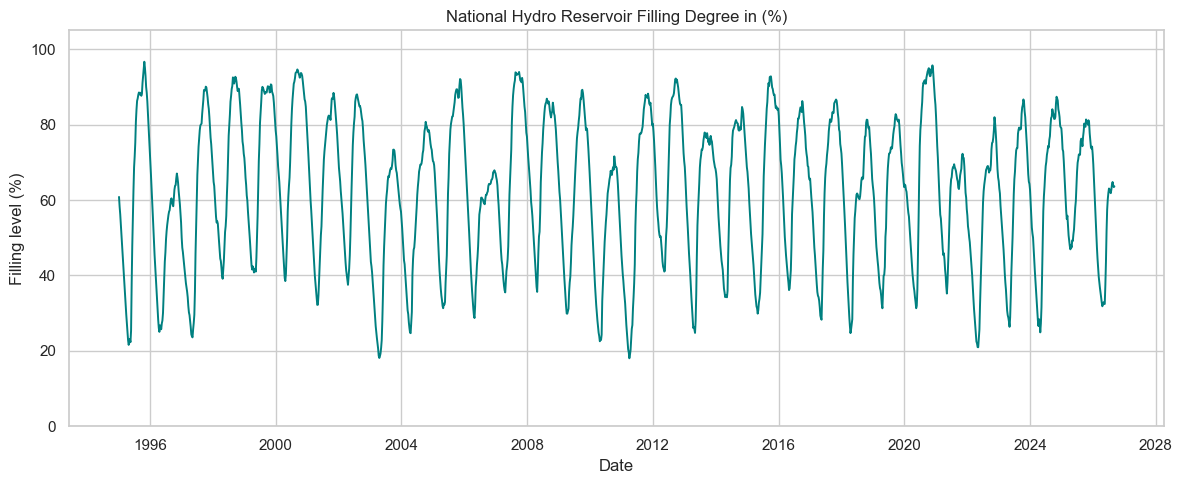

C:\Users\olive\AppData\Local\Temp\ipykernel_51320\1718955114.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=capacity_by_area, x='Area_Number', y='Capacity_TWh', palette='Blues_d')


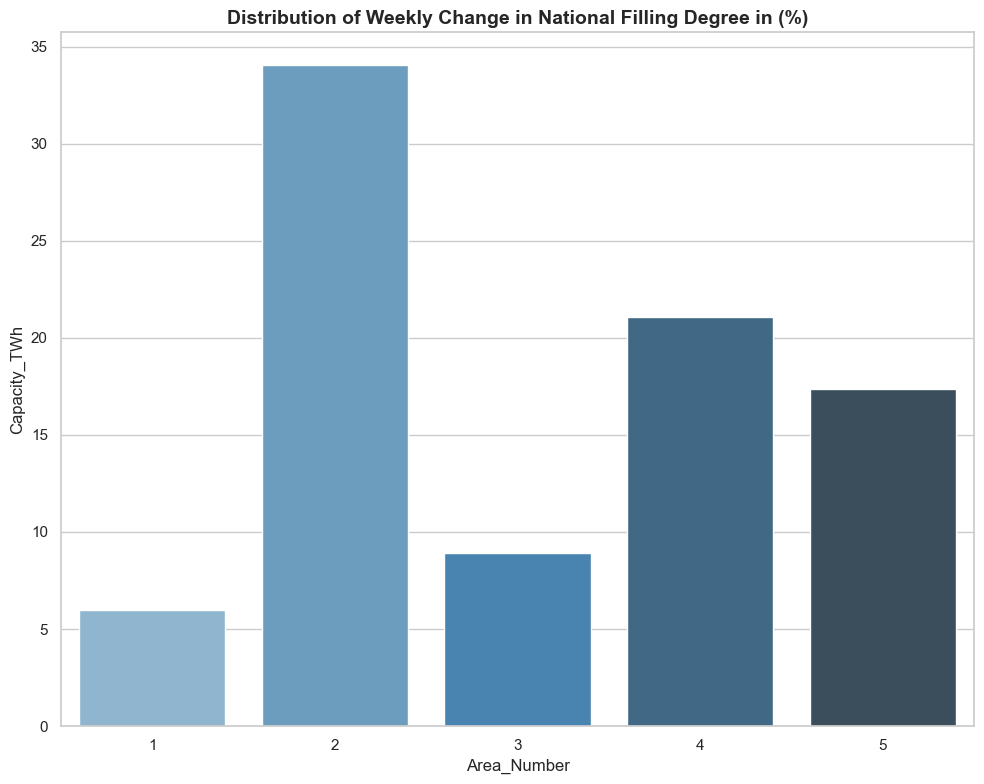

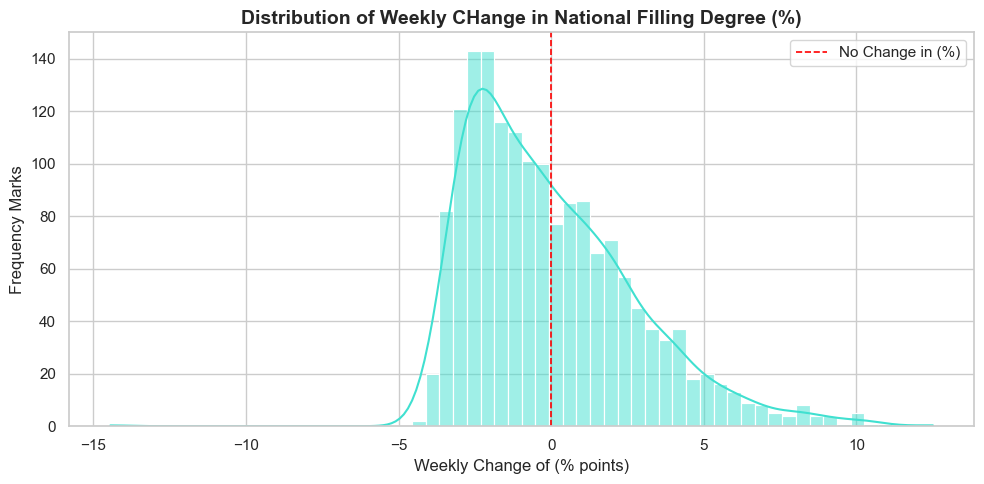

C:\Users\olive\AppData\Local\Temp\ipykernel_51320\1718955114.py:38: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 100)` for the same effect.

  sns.lineplot(data=df_no,x = 'Iso_Week', y=df_no['Fillings_Degree'] * 100, color='Pink', ci=100)


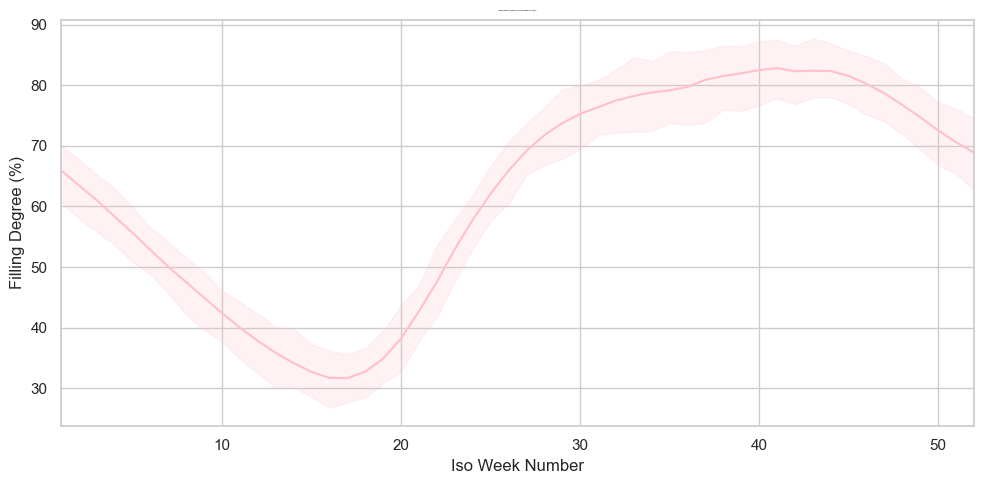

In [17]:
sns.set_theme(style="whitegrid")

df = pd.read_csv('reservoirs_improved.csv')
df['Date'] = pd.to_datetime(df['Date'])

df_no = df[df['Area_Type'] == 'NO'].sort_values('Date')
df_el = df[df['Area_Type'] == 'EL'].sort_values('Date')


plt.figure(figsize=(12,5))
plt.plot(df_no['Date'], df_no['Fillings_Degree'] * 100, color='teal', linewidth=1.4, label = 'Filling Degree in (%)')
plt.title('National Hydro Reservoir Filling Degree in (%)')
plt.xlabel('Date')
plt.ylabel('Filling level (%)')
plt.ylim(0, 105)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
capacity_by_area = df_el.groupby('Area_Number')['Capacity_TWh'].max().reset_index()
sns.barplot(data=capacity_by_area, x='Area_Number', y='Capacity_TWh', palette='Blues_d')
plt.title('Distribution of Weekly Change in National Filling Degree in (%)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,5))
sns.histplot(df_no['Change_Filling_Degree'] * 100, bins=60, kde=True, color='turquoise')
plt.axvline(0, color='red', linestyle='--', linewidth=1.2, label='No Change in (%)')
plt.title('Distribution of Weekly CHange in National Filling Degree (%)', fontsize=14, fontweight='bold')
plt.xlabel('Weekly Change of (% points)')
plt.ylabel('Frequency Marks')
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(10,5))
sns.lineplot(data=df_no,x = 'Iso_Week', y=df_no['Fillings_Degree'] * 100, color='Pink', ci=100)
plt.title('Average Seasonal Trajectory of Filling Degree by Iso Week', fontsize=1, fontweight='bold')
plt.xlabel('Iso Week Number')
plt.ylabel('Filling Degree (%)')
plt.xlim(1, 52)
plt.tight_layout()
plt.show()



Furthermore, the task implied to plot them again seperately, but keeping in mind that the scaling was different. This is solved as done below, by defining several lines and axes. Finally these are added together for a better overview of all the graphs together. 

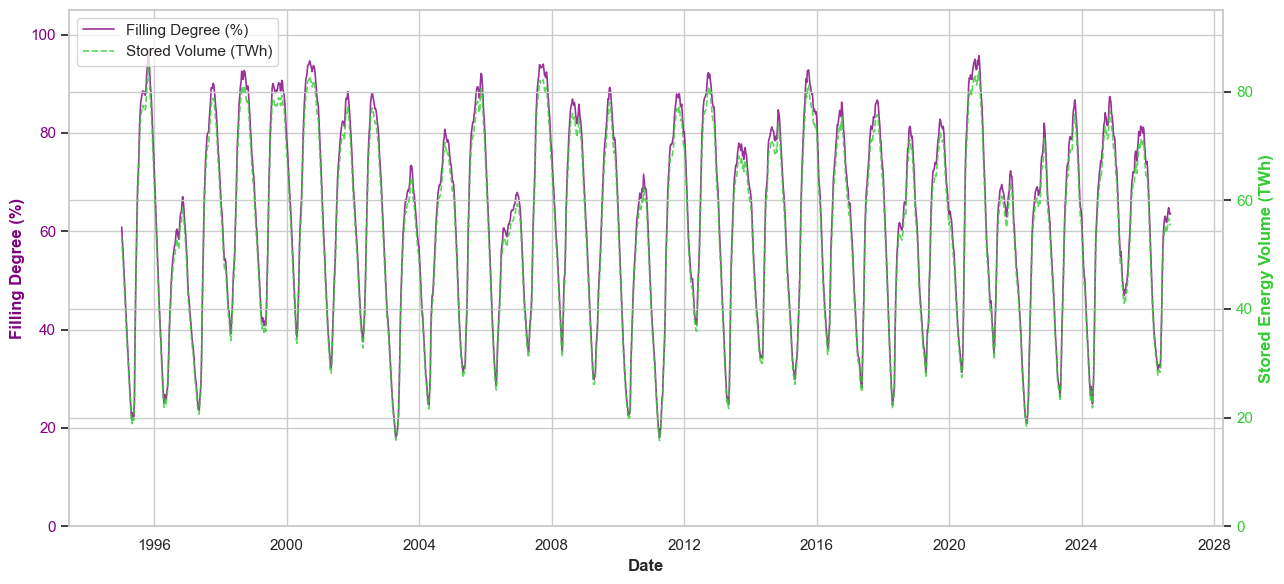

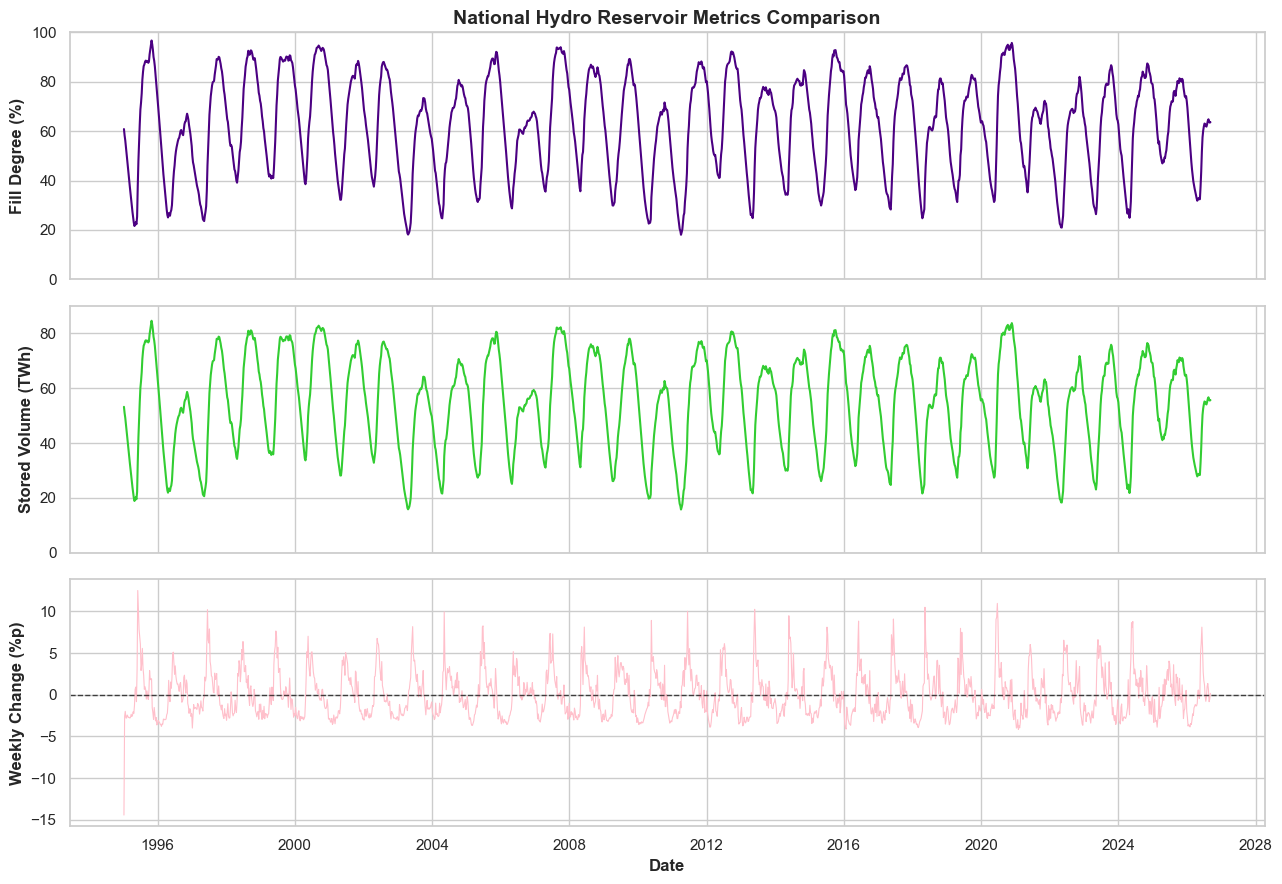

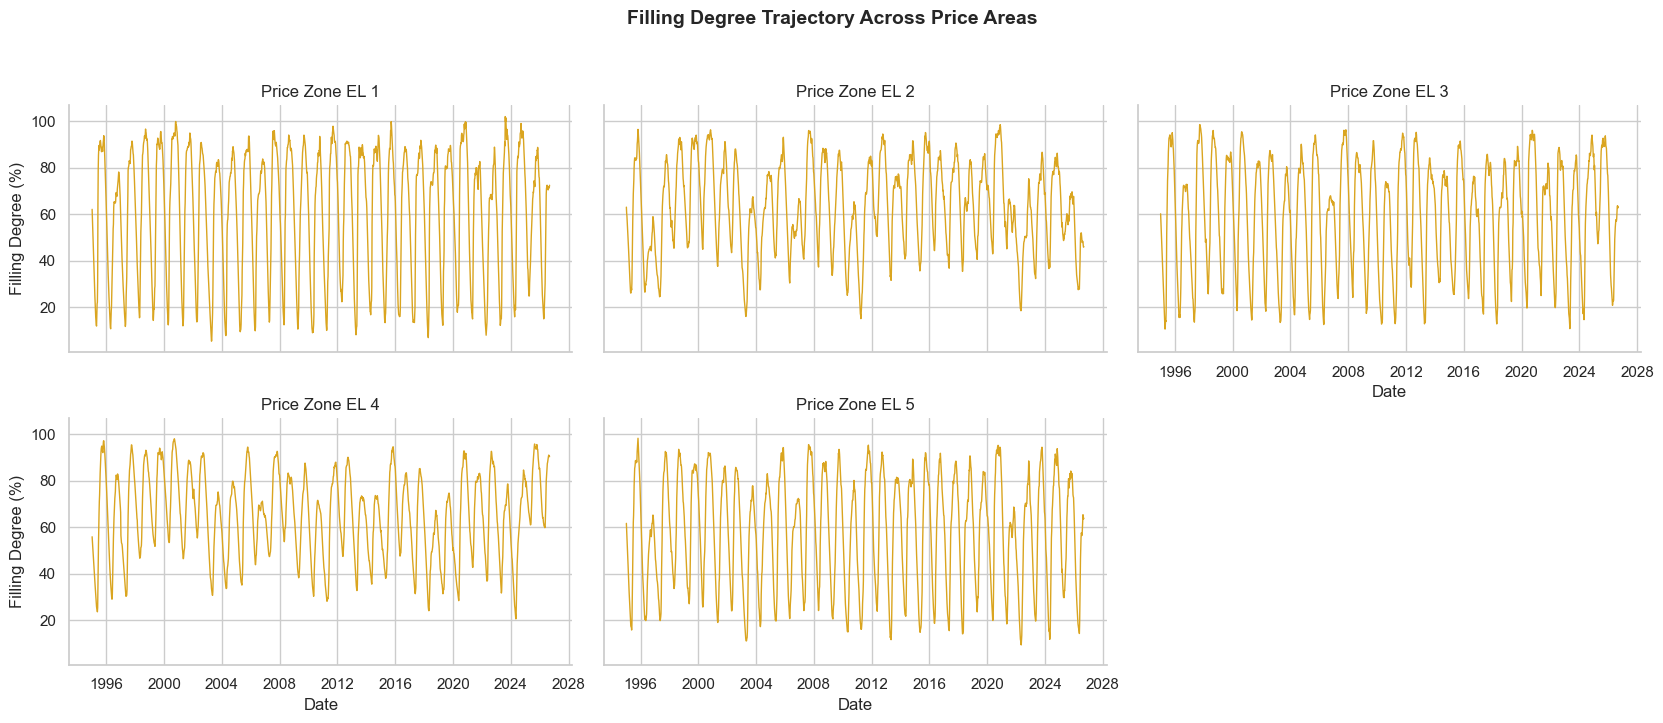

In [18]:

sns.set_theme(style="whitegrid")

#Extract the dataframe from earlier
df = pd.read_csv("reservoirs_improved.csv")
df["Date"] = pd.to_datetime(df["Date"])

#Sort by areatype to later and sort by date

df_no = df[df["Area_Type"] == "NO"].sort_values("Date").reset_index(drop=True)

fig, ax1 = plt.subplots(figsize=(13, 6))
#First line 
line1 = ax1.plot(
    df_no["Date"],
    df_no["Fillings_Degree"] * 100,
    color="purple",
    linewidth=1.2,
    alpha=0.8,
    label="Filling Degree (%)",
)
ax1.set_xlabel("Date", fontsize=12, fontweight="bold")
ax1.set_ylabel(
    "Filling Degree (%)", color="purple", fontsize=12, fontweight="bold"
)
ax1.tick_params(axis="y", labelcolor="purple")
ax1.set_ylim(0, 105)

#Second line
ax2 = ax1.twinx()
line2 = ax2.plot(
    df_no["Date"],
    df_no["Filling_TWh"],
    color="limegreen",
    linewidth=1.2,
    alpha=0.8,
    linestyle="--",
    label="Stored Volume (TWh)",
)
ax2.set_ylabel(
    "Stored Energy Volume (TWh)",
    color="limegreen",
    fontsize=12,
    fontweight="bold",
)
ax2.tick_params(axis="y", labelcolor="limegreen")
ax2.set_ylim(0, 95)

lines = line1 + line2
ax1.legend(lines, [l.get_label() for l in lines], loc="upper left", frameon=True)

plt.tight_layout()
plt.show()


fig, (ax_top, ax_mid, ax_bot) = plt.subplots(3, 1, figsize=(13, 9), sharex=True)


ax_top.plot(df_no["Date"], df_no["Fillings_Degree"] * 100, color="indigo")
ax_top.set_ylabel("Fill Degree (%)", fontweight="bold")
ax_top.set_ylim(0, 100)
ax_top.set_title(
    "National Hydro Reservoir Metrics Comparison",
    fontsize=14,
    fontweight="bold",
)


ax_mid.plot(df_no["Date"], df_no["Filling_TWh"], color="limegreen")
ax_mid.set_ylabel("Stored Volume (TWh)", fontweight="bold")
ax_mid.set_ylim(0, 90)


ax_bot.plot(
    df_no["Date"],
    df_no["Change_Filling_Degree"] * 100,
    color="pink",
    linewidth=0.8,
)
ax_bot.axhline(0, color="black", linestyle="--", alpha=0.7, linewidth=1)
ax_bot.set_ylabel("Weekly Change (%p)", fontweight="bold")
ax_bot.set_xlabel("Date", fontweight="bold")

plt.tight_layout()
plt.show()

#Use the df_el for plotting the areanumbers and zones. 
df_el = (
    df[df["Area_Type"] == "EL"]
    .sort_values(by=["Area_Number", "Date"])
    .reset_index(drop=True)
)
df_el["Filling_Degree_Pct"] = df_el["Fillings_Degree"] * 100

g = sns.FacetGrid(
    df_el, col="Area_Number", col_wrap=3, height=3.5, aspect=1.6, sharey=True
)


g.map_dataframe(
    sns.lineplot, x="Date", y="Filling_Degree_Pct", color="goldenrod", linewidth=1
)

g.set_axis_labels("Date", "Filling Degree (%)")
g.set_titles(col_template="Price Zone EL {col_name}")
g.fig.suptitle(
    "Filling Degree Trajectory Across Price Areas",
    fontsize=14,
    fontweight="bold",
    y=1.03,
)

plt.tight_layout()
plt.show()